## 1. Simulation Configuration & Physical Constants
 
**Mathematical Foundation:**
The simulation is based on the **Lighthill-Whitham-Richards (LWR)** model, which treats traffic as a compressible fluid. To simulate this on a computer, we discretize the continuous PDE into the **Cell Transmission Model (CTM)**.

**Key Parameters:**
* **$\Delta x$ (`CELL_LENGTH_M`):** The spatial discretization step (50m).
* **$\Delta t$ (`TIME_STEP_S`):** The temporal discretization step (5s).
* **$p_{max}$ (`MAX_CARS_PER_CELL`):** The Jam Density. From the fundamental diagram, this is the maximum number of cars that can fit in $\Delta x$.
* **$v_{max}$ (`WAVE_SPEED`):** The Free Flow speed.
 
**Simulation Scope:**
* **Grid:** A $4 \times 4$ "Tian" network (16 intersections).
* **Inflow Rate ($\lambda$):** The rate at which vehicles enter the system boundaries (Poisson process approximation).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. CONFIGURATION
# ==========================================
CONFIG = {
    "CELL_LENGTH_M": 50,
    "ROAD_LENGTH_CELLS": 20,
    "MAX_CARS_PER_CELL": 7.0,
    "WAVE_SPEED": 1.0,
    "TIME_STEP_S": 5,
    "DURATION_STEPS": 1000,
    "GRID_ROWS": 10,
    "GRID_COLS": 10,
    "INFLOW_RATE": 0.35,      
    "MIN_GREEN_STEPS": 3,
    "MAX_RED_STEPS": 24,
}

## 2. The Physics Engine: DirectedRoad Class
**Mathematical Foundation:**
This class implements the **Conservation Law**:
$$ \frac{\partial p}{\partial t} + \frac{\partial f}{\partial x} = 0 $$

In the discrete CTM form, the update rule for cell $i$ is:
$$ p_i(t+1) = p_i(t) + f_{i-1 \to i}(t) - f_{i \to i+1}(t) $$

**The Flux Function (Fundamental Diagram):**
The flow $f$ between cells is constrained by **Demand (Upstream)** and **Supply (Downstream)**:
$$ f_{i \to i+1} = \min(D_i, S_{i+1}) $$
* **Demand ($D_i$):** $D_i = \min(v_{max} p_i, C_{max})$
* **Supply ($S_{i+1}$):** $S_{i+1} = \min(w (p_{max} - p_{i+1}), C_{max})$

This ensures the **"Shockwave"** property: if a cell is full ($p=p_{max}$), Supply becomes 0, and flow stops, propagating the jam backward.


In [10]:
# ==========================================
# 2. PHYSICS ENGINE
# ==========================================
class DirectedRoad:
    def __init__(self, id, u, v, is_boundary=False):
        self.id = id; self.u = u; self.v = v
        self.cells = np.zeros(CONFIG["ROAD_LENGTH_CELLS"])
        self.is_boundary = is_boundary
        
    def get_demand(self):
        return min(CONFIG["WAVE_SPEED"] * self.cells[-1], CONFIG["MAX_CARS_PER_CELL"])

    def get_supply(self):
        return max(0.0, CONFIG["MAX_CARS_PER_CELL"] - self.cells[0])

    def get_total_cars(self):
        return np.sum(self.cells)
        
    def get_stopped_queue(self):
        # Cars with density > 2.0 are considered "Waiting"
        return np.sum(self.cells[self.cells > 2.0])

    def step_physics(self, flow_in, flow_out):
        self.cells[-1] = max(0, self.cells[-1] - flow_out)
        self.cells[0] += flow_in
        new_cells = np.copy(self.cells)
        for i in range(len(self.cells) - 2, -1, -1):
            flux = min(self.cells[i], CONFIG["MAX_CARS_PER_CELL"] - self.cells[i+1])
            new_cells[i] -= flux
            new_cells[i+1] += flux
        self.cells = new_cells

class Intersection:
    def __init__(self, id):
        self.id = id
        self.in_roads = {}
        self.out_roads = {}
        self.phase = 0 
        self.phase_timer = 0
        
    def get_pressure(self):
        p_ns = 0; p_ew = 0
        
        # Calculate Pressure = Incoming_Stopped - Outgoing_Total
        if 'N' in self.in_roads: 
            p_ns += self.in_roads['N'].get_stopped_queue()
            if 'S' in self.out_roads: p_ns -= self.out_roads['S'].get_total_cars() * 0.5
        if 'S' in self.in_roads: 
            p_ns += self.in_roads['S'].get_stopped_queue()
            if 'N' in self.out_roads: p_ns -= self.out_roads['N'].get_total_cars() * 0.5

        if 'E' in self.in_roads: 
            p_ew += self.in_roads['E'].get_stopped_queue()
            if 'W' in self.out_roads: p_ew -= self.out_roads['W'].get_total_cars() * 0.5
        if 'W' in self.in_roads: 
            p_ew += self.in_roads['W'].get_stopped_queue()
            if 'E' in self.out_roads: p_ew -= self.out_roads['E'].get_total_cars() * 0.5
            
        return max(0.1, p_ns), max(0.1, p_ew)

    def step_flow(self):
        transfers = [] 
        allowed_dirs = ['N', 'S'] if self.phase == 0 else ['E', 'W']
        for s_dir in allowed_dirs:
            if s_dir not in self.in_roads: continue
            source = self.in_roads[s_dir]
            target_map = {'N':'S', 'S':'N', 'E':'W', 'W':'E'}
            t_dir = target_map[s_dir]
            demand = source.get_demand()
            
            if t_dir not in self.out_roads:
                transfers.append((source, "EXIT", demand))
            else:
                target = self.out_roads[t_dir]
                supply = target.get_supply()
                flow = min(demand, supply)
                if flow > 0: transfers.append((source, target, flow))
        return transfers

## 3. The Node Model: Intersection Class
**Mathematical Foundation:**
The intersection acts as a **Flow Regulator**.
$$ f_{i \to j}(t) = s_{i}(t) \cdot \min(D_i, S_j) $$
* $s_i(t)$: The binary Traffic Signal State (1 if Green, 0 if Red).
**The Algorithm: Max Pressure Control**
The "Smart Agent" uses the **Max Pressure** algorithm, which is a decentralized control policy proven to maximize throughput.

$$ \text{Pressure}_i = \sum w_{\text{incoming}} - \sum w_{\text{outgoing}} $$

* The agent calculates the "Pressure" for North-South vs. East-West.
* It greedily switches to the phase with higher pressure, effectively "balancing" the fluid levels across the node.


In [11]:
# ==========================================
# 3. NETWORK
# ==========================================
class TianGrid:
    def __init__(self):
        self.roads = []
        self.intersections = {}
        self.build()
        self.total_throughput = 0.0 # METRIC: Cars that exited
        
    def build(self):
        rows, cols = CONFIG["GRID_ROWS"], CONFIG["GRID_COLS"]
        for r in range(rows):
            for c in range(cols):
                nid = f"{r}-{c}"
                self.intersections[nid] = Intersection(nid)
                
        for r in range(rows):
            for c in range(cols):
                u = self.intersections[f"{r}-{c}"]
                if c < cols - 1: 
                    v = self.intersections[f"{r}-{c+1}"]
                    is_bound_e = (c == 0) 
                    r1 = DirectedRoad(f"R_E_{r}_{c}", u.id, v.id, is_boundary=is_bound_e)
                    is_bound_w = (c+1 == cols - 1)
                    r2 = DirectedRoad(f"R_W_{r}_{c}", v.id, u.id, is_boundary=is_bound_w)
                    u.out_roads['E'] = r1; v.in_roads['W'] = r1
                    v.out_roads['W'] = r2; u.in_roads['E'] = r2
                    self.roads.extend([r1, r2])
                    
                if r < rows - 1: 
                    v = self.intersections[f"{r+1}-{c}"]
                    is_bound_s = (r == 0)
                    r1 = DirectedRoad(f"R_S_{r}_{c}", u.id, v.id, is_boundary=is_bound_s)
                    is_bound_n = (r+1 == rows - 1)
                    r2 = DirectedRoad(f"R_N_{r}_{c}", v.id, u.id, is_boundary=is_bound_n)
                    u.out_roads['S'] = r1; v.in_roads['N'] = r1
                    v.out_roads['N'] = r2; u.in_roads['S'] = r2
                    self.roads.extend([r1, r2])

    def step(self):
        transfers = []
        for i in self.intersections.values():
            transfers.extend(i.step_flow())
            
        inflows = {r.id: 0.0 for r in self.roads}
        outflows = {r.id: 0.0 for r in self.roads}
        
        for src, tgt, amt in transfers:
            outflows[src.id] += amt
            if tgt == "EXIT":
                self.total_throughput += amt # METRIC: Count cars leaving
            else:
                inflows[tgt.id] += amt
                
        for r in self.roads:
            r.step_physics(inflows[r.id], outflows[r.id])
            
        for r in self.roads:
            if r.is_boundary or r.cells[0] < 1.0:
                 u_node = self.intersections[r.u]
                 is_entry = False
                 if "R_E" in r.id and 'W' not in u_node.in_roads: is_entry = True
                 if "R_W" in r.id and 'E' not in u_node.in_roads: is_entry = True
                 if "R_S" in r.id and 'N' not in u_node.in_roads: is_entry = True
                 if "R_N" in r.id and 'S' not in u_node.in_roads: is_entry = True
                 
                 if is_entry and random.random() < CONFIG["INFLOW_RATE"]:
                      r.cells[0] += 2.0

    def get_metrics(self):
        total_cars = sum([r.get_total_cars() for r in self.roads])
        total_stopped = sum([r.get_stopped_queue() for r in self.roads])
        return total_cars, total_stopped, self.total_throughput


## 4. The Network: TianGrid Class
**Mathematical Foundation:**
Defines the Graph $G = (V, E)$.
* **$V$ (Nodes):** `self.intersections`
* **$E$ (Edges):** `self.roads`
 
This class acts as the **Global System State**, managing the synchronization of physics steps and data collection.

In [12]:
# ==========================================
# 4. SIMULATION LOOP (With Metrics)
# ==========================================
def run_simulation(mode="fixed"):
    env = TianGrid()
    history = {
        "total_cars": [],
        "stopped_cars": [],
        "throughput": []
    }
    
    for t in range(CONFIG["DURATION_STEPS"]):
        for node in env.intersections.values():
            node.phase_timer += 1
            if mode == "fixed":
                if node.phase_timer >= 6:
                    node.phase = 1 - node.phase
                    node.phase_timer = 0
            elif mode == "smart":
                if node.phase_timer >= CONFIG["MAX_RED_STEPS"]:
                    node.phase = 1 - node.phase
                    node.phase_timer = 0
                elif node.phase_timer >= CONFIG["MIN_GREEN_STEPS"]:
                    p_ns, p_ew = node.get_pressure()
                    if node.phase == 0 and p_ew > p_ns:
                        node.phase = 1; node.phase_timer = 0
                    elif node.phase == 1 and p_ns > p_ew:
                        node.phase = 0; node.phase_timer = 0
                        
        env.step()
        
        tc, ts, tp = env.get_metrics()
        history["total_cars"].append(tc)
        history["stopped_cars"].append(ts) # Proxy for Waiting Time
        history["throughput"].append(tp)
        
    return history

## 5. Simulation Loop & Comparative Analysis
**The Experiment:**
We run two parallel simulations to evaluate the **Objective Function**: $$ J = \sum_{t=0}^T \sum_{i \in V} p^{wait}_i(t) $$ 
**1. Baseline (Fixed Time):**
* Policy: Switch phase every $k$ seconds (Static).
* Equation: $a_t = 1 - a_{t-1}$ if $t\mod k == 0$.

**2. Smart Agent (Max Pressure):**
* Policy: Switch if Pressure Gradient favors the other phase.
* Equation: $a_t = \arg\max_k (P_k)$.

**Metrics Visualized:**
1.  **Global Congestion:** Total density $\int p(x,t) dx$.
2.  **Throughput:** Total flux exiting the system.
3.  **Waiting Time:** Proxy for the primary minimization objective.

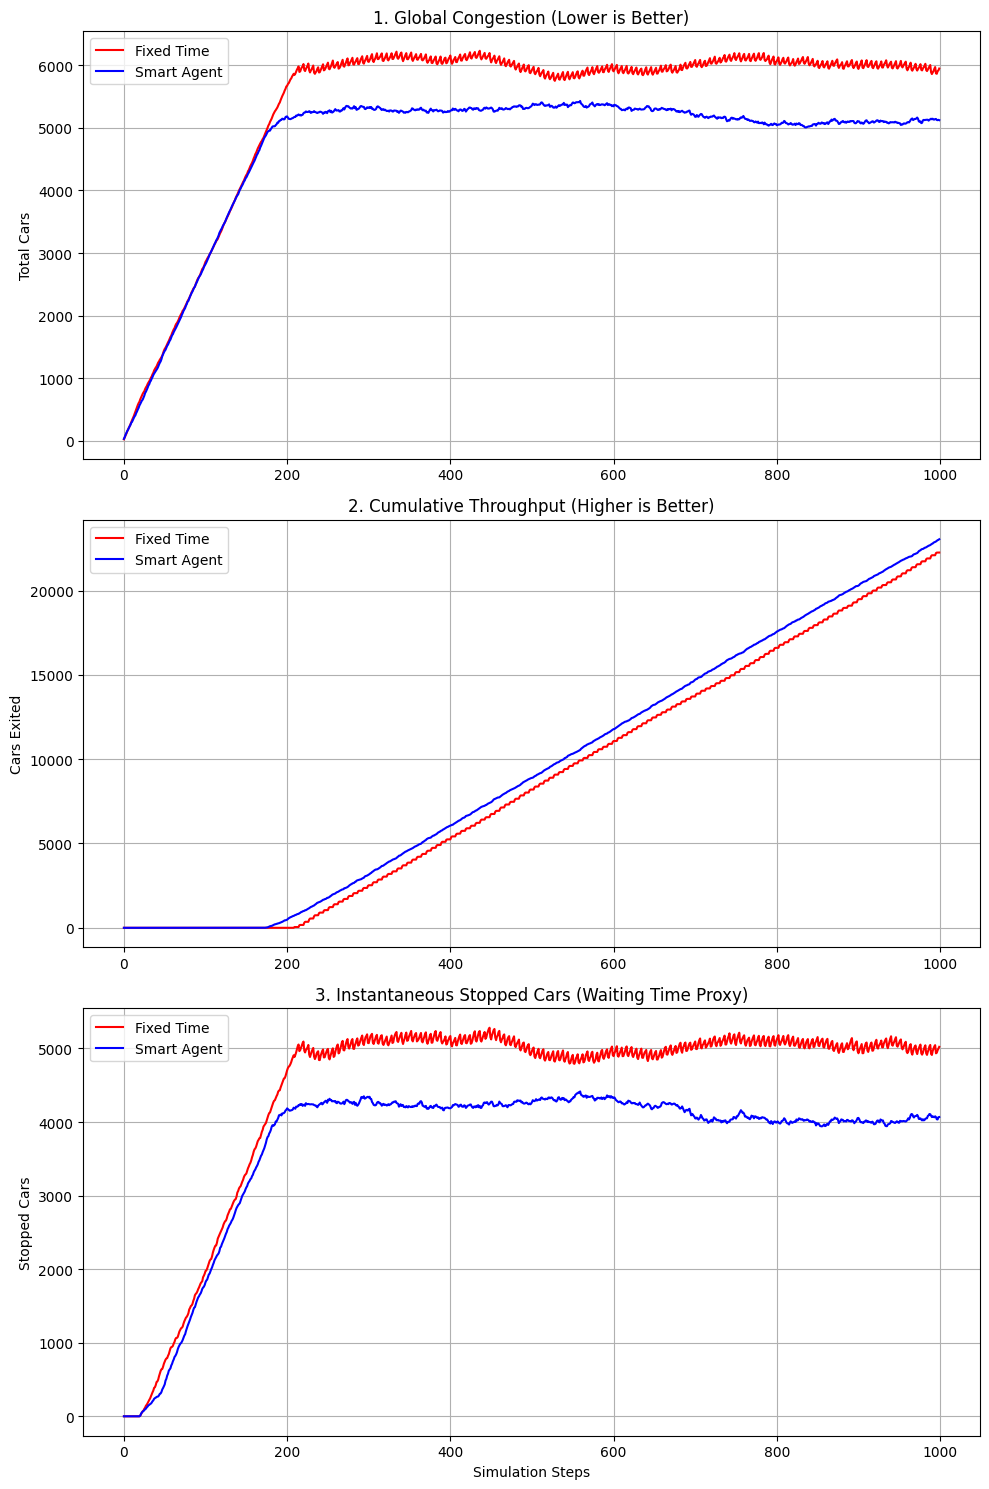


=== FINAL METRICS ===
Total Throughput (Fixed): 22254
Total Throughput (Smart): 23042
Avg Stopped Cars (Fixed): 4434.3
Avg Stopped Cars (Smart): 3705.1
Wait Time Reduction: 16.4%


In [13]:
fixed = run_simulation("fixed")
smart = run_simulation("smart")

# --- DASHBOARD PLOTTING ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Total Cars (Congestion)
ax1.plot(fixed["total_cars"], label='Fixed Time', color='red')
ax1.plot(smart["total_cars"], label='Smart Agent', color='blue')
ax1.set_title('1. Global Congestion (Lower is Better)')
ax1.set_ylabel('Total Cars')
ax1.legend()
ax1.grid(True)

# Plot 2: Throughput (Efficiency)
ax2.plot(fixed["throughput"], label='Fixed Time', color='red')
ax2.plot(smart["throughput"], label='Smart Agent', color='blue')
ax2.set_title('2. Cumulative Throughput (Higher is Better)')
ax2.set_ylabel('Cars Exited')
ax2.legend()
ax2.grid(True)

# Plot 3: Stopped Cars (Waiting Time)
ax3.plot(fixed["stopped_cars"], label='Fixed Time', color='red')
ax3.plot(smart["stopped_cars"], label='Smart Agent', color='blue')
ax3.set_title('3. Instantaneous Stopped Cars (Waiting Time Proxy)')
ax3.set_ylabel('Stopped Cars')
ax3.set_xlabel('Simulation Steps')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

# --- SUMMARY STATS ---
print("\n=== FINAL METRICS ===")
print(f"Total Throughput (Fixed): {fixed['throughput'][-1]:.0f}")
print(f"Total Throughput (Smart): {smart['throughput'][-1]:.0f}")

avg_wait_fixed = np.mean(fixed["stopped_cars"])
avg_wait_smart = np.mean(smart["stopped_cars"])
print(f"Avg Stopped Cars (Fixed): {avg_wait_fixed:.1f}")
print(f"Avg Stopped Cars (Smart): {avg_wait_smart:.1f}")

print(f"Wait Time Reduction: {(avg_wait_fixed - avg_wait_smart) / avg_wait_fixed * 100:.1f}%")

Starting Scalability Experiment...
  Simulating 2x2 Grid...
  Simulating 4x4 Grid...
  Simulating 6x6 Grid...
  Simulating 8x8 Grid...
  Simulating 10x10 Grid...
  Simulating 12x12 Grid...
  Simulating 14x14 Grid...
  Simulating 16x16 Grid...
  Simulating 18x18 Grid...
  Simulating 20x20 Grid...


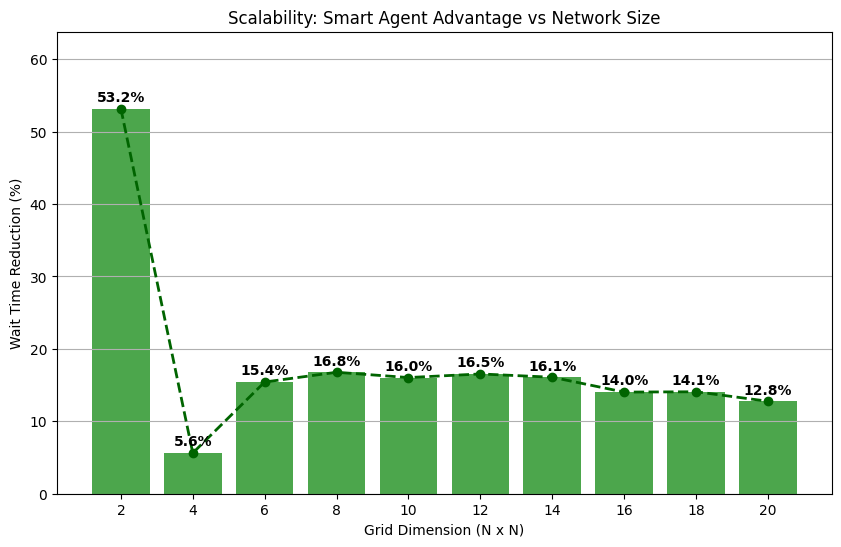

In [7]:
# %% [markdown]
# # Adaptive Traffic Control: Scalability Analysis
# 
# ## Experiment Design: The Impact of Network Scale
# 
# To validate the hypothesis that adaptive control becomes increasingly superior as network complexity grows, we perform a **Sensitivity Analysis**.
# 
# **Independent Variable:**
# * Grid Size $N$: We test $N \times N$ grids for $N \in \{4, 8, 12\}$.
# 
# **Dependent Variable:**
# * Performance Improvement ($\Delta J$): The percentage reduction in waiting time compared to the Fixed-Time baseline.
# 
# $$ \Delta J(N) = \frac{J_{fixed}(N) - J_{smart}(N)}{J_{fixed}(N)} \times 100\% $$

# %%
import numpy as np
import matplotlib.pyplot as plt
import random

CONFIG = {
    # --- PHYSICAL CONSTANTS ---
    "CELL_LENGTH_M": 50,
    "ROAD_LENGTH_CELLS": 20,
    "MAX_CARS_PER_CELL": 7.0,
    "WAVE_SPEED": 1.0,
    
    # --- SIMULATION ---
    "TIME_STEP_S": 5,
    "DURATION_STEPS": 1000,     # Slightly reduced for speed during multi-grid test
    "INFLOW_RATE": 0.35,       
    
    # --- CONTROL ---
    "MIN_GREEN_STEPS": 3,
    "MAX_RED_STEPS": 24,
}

# %% [markdown]
# ## Physics & Network Classes (Reused)
# Standard CTM physics and Max Pressure logic.

# %%
class DirectedRoad:
    def __init__(self, id, u, v, is_boundary=False):
        self.id = id; self.u = u; self.v = v
        self.cells = np.zeros(CONFIG["ROAD_LENGTH_CELLS"])
        self.is_boundary = is_boundary
        
    def get_demand(self):
        return min(CONFIG["WAVE_SPEED"] * self.cells[-1], CONFIG["MAX_CARS_PER_CELL"])

    def get_supply(self):
        return max(0.0, CONFIG["MAX_CARS_PER_CELL"] - self.cells[0])

    def get_total_cars(self):
        return np.sum(self.cells)
        
    def get_stopped_queue(self):
        return np.sum(self.cells[self.cells > 2.0])

    def step_physics(self, flow_in, flow_out):
        self.cells[-1] = max(0, self.cells[-1] - flow_out)
        self.cells[0] += flow_in
        new_cells = np.copy(self.cells)
        for i in range(len(self.cells) - 2, -1, -1):
            flux = min(self.cells[i], CONFIG["MAX_CARS_PER_CELL"] - self.cells[i+1])
            new_cells[i] -= flux
            new_cells[i+1] += flux
        self.cells = new_cells

class Intersection:
    def __init__(self, id):
        self.id = id
        self.in_roads = {}
        self.out_roads = {}
        self.phase = 0 
        self.phase_timer = 0
        
    def get_pressure(self):
        p_ns = 0; p_ew = 0
        if 'N' in self.in_roads: 
            p_ns += self.in_roads['N'].get_stopped_queue()
            if 'S' in self.out_roads: p_ns -= self.out_roads['S'].get_total_cars() * 0.5
        if 'S' in self.in_roads: 
            p_ns += self.in_roads['S'].get_stopped_queue()
            if 'N' in self.out_roads: p_ns -= self.out_roads['N'].get_total_cars() * 0.5

        if 'E' in self.in_roads: 
            p_ew += self.in_roads['E'].get_stopped_queue()
            if 'W' in self.out_roads: p_ew -= self.out_roads['W'].get_total_cars() * 0.5
        if 'W' in self.in_roads: 
            p_ew += self.in_roads['W'].get_stopped_queue()
            if 'E' in self.out_roads: p_ew -= self.out_roads['E'].get_total_cars() * 0.5
            
        return max(0.1, p_ns), max(0.1, p_ew)

    def step_flow(self):
        transfers = [] 
        allowed_dirs = ['N', 'S'] if self.phase == 0 else ['E', 'W']
        for s_dir in allowed_dirs:
            if s_dir not in self.in_roads: continue
            source = self.in_roads[s_dir]
            target_map = {'N':'S', 'S':'N', 'E':'W', 'W':'E'}
            t_dir = target_map[s_dir]
            demand = source.get_demand()
            
            if t_dir not in self.out_roads:
                transfers.append((source, "EXIT", demand))
            else:
                target = self.out_roads[t_dir]
                supply = target.get_supply()
                flow = min(demand, supply)
                if flow > 0: transfers.append((source, target, flow))
        return transfers

class TianGrid:
    def __init__(self, size):
        self.roads = []
        self.intersections = {}
        self.size = size # N x N
        self.build()
        self.total_throughput = 0.0
        
    def build(self):
        rows, cols = self.size, self.size
        for r in range(rows):
            for c in range(cols):
                nid = f"{r}-{c}"
                self.intersections[nid] = Intersection(nid)
                
        for r in range(rows):
            for c in range(cols):
                u = self.intersections[f"{r}-{c}"]
                if c < cols - 1: 
                    v = self.intersections[f"{r}-{c+1}"]
                    r1 = DirectedRoad(f"R_E_{r}_{c}", u.id, v.id, is_boundary=(c==0))
                    r2 = DirectedRoad(f"R_W_{r}_{c}", v.id, u.id, is_boundary=(c+1==cols-1))
                    u.out_roads['E'] = r1; v.in_roads['W'] = r1
                    v.out_roads['W'] = r2; u.in_roads['E'] = r2
                    self.roads.extend([r1, r2])
                if r < rows - 1: 
                    v = self.intersections[f"{r+1}-{c}"]
                    r1 = DirectedRoad(f"R_S_{r}_{c}", u.id, v.id, is_boundary=(r==0))
                    r2 = DirectedRoad(f"R_N_{r}_{c}", v.id, u.id, is_boundary=(r+1==rows-1))
                    u.out_roads['S'] = r1; v.in_roads['N'] = r1
                    v.out_roads['N'] = r2; u.in_roads['S'] = r2
                    self.roads.extend([r1, r2])

    def step(self):
        transfers = []
        for i in self.intersections.values():
            transfers.extend(i.step_flow())
        inflows = {r.id: 0.0 for r in self.roads}
        outflows = {r.id: 0.0 for r in self.roads}
        for src, tgt, amt in transfers:
            outflows[src.id] += amt
            if tgt == "EXIT": self.total_throughput += amt
            else: inflows[tgt.id] += amt
        for r in self.roads:
            r.step_physics(inflows[r.id], outflows[r.id])
        for r in self.roads:
            if r.is_boundary or r.cells[0] < 1.0:
                 u_node = self.intersections[r.u]
                 is_entry = False
                 if "R_E" in r.id and 'W' not in u_node.in_roads: is_entry = True
                 if "R_W" in r.id and 'E' not in u_node.in_roads: is_entry = True
                 if "R_S" in r.id and 'N' not in u_node.in_roads: is_entry = True
                 if "R_N" in r.id and 'S' not in u_node.in_roads: is_entry = True
                 if is_entry and random.random() < CONFIG["INFLOW_RATE"]:
                      r.cells[0] += 2.0

    def get_metrics(self):
        total_cars = sum([r.get_total_cars() for r in self.roads])
        total_stopped = sum([r.get_stopped_queue() for r in self.roads])
        return total_cars, total_stopped, self.total_throughput

# %% [markdown]
# ## Multi-Grid Simulation Loop
# We now run the simulation for `GRID_SIZES = [4, 8, 12]` to measure how the improvement scales.

# %%
def run_experiment_suite():
    GRID_SIZES = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
    results_summary = {
        "size": [],
        "imp_wait": [],
        "raw_fixed_wait": [],
        "raw_smart_wait": []
    }
    
    print(f"Starting Scalability Experiment...")
    
    for N in GRID_SIZES:
        print(f"  Simulating {N}x{N} Grid...")
        
        # --- FIXED TIME RUN ---
        env_fixed = TianGrid(N)
        fixed_wait_history = []
        for t in range(CONFIG["DURATION_STEPS"]):
            for node in env_fixed.intersections.values():
                node.phase_timer += 1
                if node.phase_timer >= 6:
                    node.phase = 1 - node.phase
                    node.phase_timer = 0
            env_fixed.step()
            fixed_wait_history.append(env_fixed.get_metrics()[1])
            
        # --- SMART AGENT RUN ---
        env_smart = TianGrid(N)
        smart_wait_history = []
        for t in range(CONFIG["DURATION_STEPS"]):
            for node in env_smart.intersections.values():
                node.phase_timer += 1
                if node.phase_timer >= CONFIG["MAX_RED_STEPS"]:
                    node.phase = 1 - node.phase
                    node.phase_timer = 0
                elif node.phase_timer >= CONFIG["MIN_GREEN_STEPS"]:
                    p_ns, p_ew = node.get_pressure()
                    if node.phase == 0 and p_ew > p_ns:
                        node.phase = 1; node.phase_timer = 0
                    elif node.phase == 1 and p_ns > p_ew:
                        node.phase = 0; node.phase_timer = 0
            env_smart.step()
            smart_wait_history.append(env_smart.get_metrics()[1])
            
        # --- CALCULATE METRICS ---
        avg_wait_fixed = np.mean(fixed_wait_history)
        avg_wait_smart = np.mean(smart_wait_history)
        
        improvement = (avg_wait_fixed - avg_wait_smart) / avg_wait_fixed * 100
        
        results_summary["size"].append(N)
        results_summary["imp_wait"].append(improvement)
        results_summary["raw_fixed_wait"].append(avg_wait_fixed)
        results_summary["raw_smart_wait"].append(avg_wait_smart)
        
        # print(f"    -> Size {N}x{N}: Improvement = {improvement:.2f}%")

    return results_summary


data = run_experiment_suite()

# --- PLOTTING SCALABILITY ---
plt.figure(figsize=(10, 6))

# Bar Chart for Improvement
plt.bar([str(x) for x in data["size"]], data["imp_wait"], color='green', alpha=0.7)


# Line for Trend
plt.plot([str(x) for x in data["size"]], data["imp_wait"], color='darkgreen', marker='o', linewidth=2, linestyle='--')

plt.xlabel("Grid Dimension (N x N)")
plt.ylabel("Wait Time Reduction (%)")
plt.title("Scalability: Smart Agent Advantage vs Network Size")
plt.ylim(0, max(data["imp_wait"]) * 1.2)
plt.grid(True, axis='y')

for i, v in enumerate(data["imp_wait"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
    
plt.show()

In [14]:
import pandas as pd

data_df = pd.DataFrame(data)
data_df['improvement'] = (data_df["raw_fixed_wait"] - data_df["raw_smart_wait"]) / data_df["raw_fixed_wait"] * 100
print(data_df)

   size   imp_wait  raw_fixed_wait  raw_smart_wait  improvement
0     2  53.167877           9.912           4.642    53.167877
1     4   5.621063         419.120         395.561     5.621063
2     6  15.425101        1352.983        1144.284    15.425101
3     8  16.773604        2642.658        2199.389    16.773604
4    10  16.042826        4365.247        3664.938    16.042826
5    12  16.541199        6486.120        5413.238    16.541199
6    14  16.085022        8956.780        7516.080    16.085022
7    16  14.033881       11508.677        9893.563    14.033881
8    18  14.079534       14384.425       12359.165    14.079534
9    20  12.770133       17373.977       15155.297    12.770133
